In [16]:
import pandas as pd
from src.assay_calibration.data_utils.dataset import BasicScoreset
from src.assay_calibration.fit_utils.fit import Fit
import numpy as np

In [17]:
df = pd.read_excel("/data/dzeiberg/tsc2/dataframe.xlsx")
for scoreCol in ['immuneSGEscore',
                 'cliPE_score',
                 'gnomAD4.1_joint_AC',
                 'SpliceAI_pred_DS_AG',
                'SpliceAI_pred_DS_AL',
                'SpliceAI_pred_DS_DG',
                'SpliceAI_pred_DS_DL']:
    df.loc[:,scoreCol] = pd.to_numeric(df.loc[:,scoreCol],errors='coerce')

In [18]:
df = df.assign(spliceAIMax = df.loc[:,['SpliceAI_pred_DS_AG',
                                       'SpliceAI_pred_DS_AL',
                                       'SpliceAI_pred_DS_DG',
                                       'SpliceAI_pred_DS_DL']].fillna(0.).max(axis=1))

/tmp/ipykernel_3049547/1864246316.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  'SpliceAI_pred_DS_DL']].fillna(0.).max(axis=1))


In [19]:
df.set.value_counts()

set
Missense      8891
Nonsense       471
Synonymous     362
Name: count, dtype: int64

In [20]:
df[df.spliceAIMax > 0.2]

,hgvs_pro,VAMPseq_ave,set,immuneSGEscore,cliPE_score,cliPE_se_re,set2,clinvar_id,clinvar_clnsig,gnomAD4.1_joint_AC,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,spliceAIMax
279,p.GLU1523ASP,0.965731,Missense,NaN,NaN,NaN,MIS,-,-,NaN,5,-29,48,0,0.01,0.0,0.46,0.62,TSC2,0.62
307,p.SER1524LEU,0.984960,Missense,NaN,NaN,NaN,MIS,1371331,Uncertain_significance,1.0,5,26,15,26,0.22,0.0,0.0,0.0,TSC2,0.22
322,p.GLN1525GLU,1.008041,Missense,NaN,NaN,NaN,MIS,663392,Conflicting_classifications_of_pathogenicity,3.0,1,3,1,3,0.54,0.0,0.0,0.0,TSC2,0.54
325,p.GLN1525HIS,0.977188,Missense,NaN,NaN,NaN,MIS,-,-,NaN,22,1,11,1,0.38,0.0,0.0,0.0,TSC2,0.38
328,p.GLN1525LEU,0.979147,Missense,NaN,NaN,NaN,MIS,-,-,NaN,23,2,11,2,0.26,0.0,0.0,0.0,TSC2,0.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9536,p.MET740ILE,0.954259,Missense,NaN,NaN,NaN,MIS,1998088,Uncertain_significance,NaN,42,-33,25,0,0.0,0.0,0.0,0.68,TSC2,0.68
9537,p.MET740LYS,0.125099,Missense,NaN,NaN,NaN,MIS,-,-,NaN,-32,1,1,-34,0.48,0.0,0.0,0.0,TSC2,0.48
9545,p.MET740VAL,0.735226,Missense,NaN,NaN,NaN,MIS,570811,Conflicting_classifications_of_pathogenicity,40.0,44,-31,-1,2,0.0,0.0,0.01,0.29,TSC2,0.29
9592,p.GLY743CYS,1.033498,Missense,NaN,NaN,NaN,MIS,-,-,NaN,9,1,9,1,0.33,0.0,0.0,0.0,TSC2,0.33


In [21]:
df.clinvar_clnsig.value_counts()

clinvar_clnsig
-                                               7618
Uncertain_significance                           912
Conflicting_classifications_of_pathogenicity     300
not_provided                                      37
Likely_pathogenic                                 35
Pathogenic                                        31
Benign                                            28
Benign/Likely_benign                              23
Pathogenic/Likely_pathogenic                      14
Likely_benign                                      8
Name: count, dtype: int64

In [22]:
scores = df.loc[:,['VAMPseq_ave','immuneSGEscore','cliPE_score']]
sample_assignments = np.zeros((scores.shape[0],scores.shape[1],4),dtype=bool)
sample_assignments[df.clinvar_clnsig.isin({'Likely_pathogenic','Pathogenic','Pathogenic/Likely_pathogenic'}) & \
                    (df.loc[:,'set'] != "Synonymous"),:,0] = True
sample_assignments[(df.clinvar_clnsig.isin({'Likely_benign','Benign','Benign/Likely_benign'})) & \
                    (df.loc[:,'set'] != "Synonymous"),:,1] = True
sample_assignments[(df.loc[:,'gnomAD4.1_joint_AC'].fillna(0) > 0) & \
                   (df.loc[:,'set'] != "Synonymous"),:,2] = True
sample_assignments[(df.loc[:,'set'] == "Synonymous"),:,3] = True
# Remove splice variants from VAMP-seq sets
sample_assignments[df.loc[:,'spliceAIMax'] > 0.2,0] = False
# Remove all variants with missing scores from all sets
sample_assignments[df.loc[:,'VAMPseq_ave'].isna(),0] = False
sample_assignments[df.loc[:,'immuneSGEscore'].isna(),1] = False
sample_assignments[df.loc[:,'cliPE_score'].isna(),2] = False

/tmp/ipykernel_3049547/570535007.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample_assignments[(df.loc[:,'gnomAD4.1_joint_AC'].fillna(0) > 0) & \


In [23]:
scoresets = [BasicScoreset(scores.loc[:,scoreset_name].values,sample_assignments[:,scoreset_num]) for \
             scoreset_num, scoreset_name in enumerate(scores.columns)]
for s_idx in range(len(scoresets)):
    scoresets[s_idx].scoreset_name = scores.columns[s_idx]

In [24]:
scoresets[0].sample_assignments.sum(0)

array([ 72,  52, 654, 362])

In [25]:
scoresets[1].sample_assignments.sum(0)

array([17,  9, 74, 34])

In [26]:
scoresets[2].sample_assignments.sum(0)

array([10,  9, 87, 14])

In [27]:
fits = [Fit(ss) for ss in scoresets]

In [ ]:
from pathlib import Path
from tqdm.auto import trange,tqdm
import pickle
local_fit_save_dir = Path("/data/dzeiberg/tsc2/fits/")
explorer_fit_save_dir = Path("/projects/talisman/dzeiberg/tsc2/fits/")
jobs_savedir = Path("/data/dzeiberg/tsc2/jobs")
jobs_savedir.mkdir(exist_ok=True,parents=True)
N_bootstraps = 20

# scoreset_fits = [fit.generate_fit_jobs([2,3],save_dir/scoreset_name,
#                                      **{"bootstrap":True,
#                                       "bootstrap_seed":bootstrap_seed}) for bootstrap_seed in trange(N_bootstraps) \
#                                         for fit,scoreset_name in zip(fits,scores.columns)]

jobNum = 0
for fit,scoreset_name in tqdm(zip(fits,scores.columns),total=len(fits)):
    for bootstrap_seed in trange(N_bootstraps,leave=False):
        jobs = fit.generate_fit_jobs([2,3],local_fit_save_dir/scoreset_name,
                                     **{"bootstrap":True,
                                      "bootstrap_seed":bootstrap_seed})
        for job in jobs:
          jobNum += 1
          job['save_dir'] = explorer_fit_save_dir / scoreset_name
          with open(jobs_savedir / f"job_{jobNum}.pkl",'wb') as f:
              pickle.dump(job,f)
          

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [28]:
from pathlib import Path
from tqdm.auto import trange,tqdm
import pickle
test_fit_save_dir = Path("/data/dzeiberg/tsc2/test_fits/")
test_jobs_savedir = Path("/data/dzeiberg/tsc2/test_jobs")
test_jobs_savedir.mkdir(exist_ok=True,parents=True)
test_jobs_savedir.mkdir(exist_ok=True,parents=True)
N_bootstraps = 20

jobNum = 0
for fit,scoreset_name in tqdm(zip(fits,scores.columns),total=len(fits)):
    for bootstrap_seed in trange(N_bootstraps,leave=False):
        jobs = fit.generate_fit_jobs([2,3],test_fit_save_dir/scoreset_name,
                                     **{"bootstrap":True,
                                      "bootstrap_seed":bootstrap_seed,
                                      "init_strategy":'kmeans'})
        for job in jobs:
          jobNum += 1
          with open(test_jobs_savedir / f"job_{jobNum}.pkl",'wb') as f:
              pickle.dump(job,f)
          

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [57]:
fit = Fit(scoresets[0])

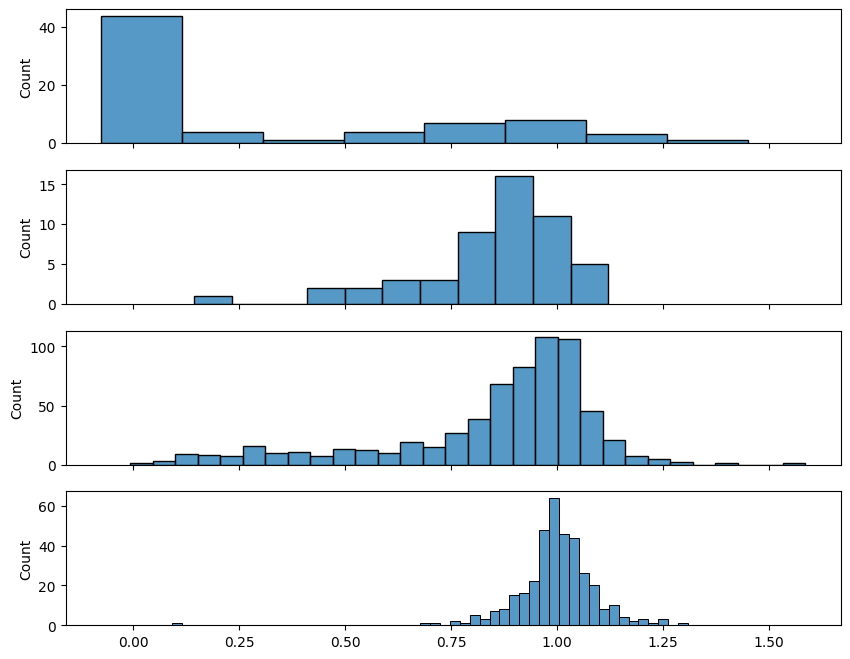

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
fig,ax = plt.subplots(scoresets[0].sample_assignments.shape[1],figsize=(10,8),sharex=True)

for sampleNum,sampleAx in enumerate(ax):
    sns.histplot(scoresets[0].scores[scoresets[0].sample_assignments[:,sampleNum]],ax=sampleAx)